DATA OVERVIEW
Dataset shape: (25, 17)
Participants: 2 (Ages: [36 38])
Gender distribution: {'female': 19, 'male': 6}

First few rows:
   Age  Height (m)  Height (in) Gender (f/m)  Ethnicity  \
0   36         1.5           59       female  Asian -PK   
1   36         1.5           59       female  Asian -PK   
2   36         1.5           59       female  Asian -PK   
3   36         1.5           59       female  Asian -PK   
4   36         1.5           59       female  Asian -PK   

  Daytime variations (morning/afternoon/evening)  FEV1 (litres)  FVC (litres)  \
0                                      afternoon           2.37          2.37   
1                                      afternoon           2.32          2.37   
2                                      afternoon           1.98          1.98   
3                                      afternoon           2.17          2.17   
4                                        evening           2.14          2.14   

   FER (%)  PEF (litre/m

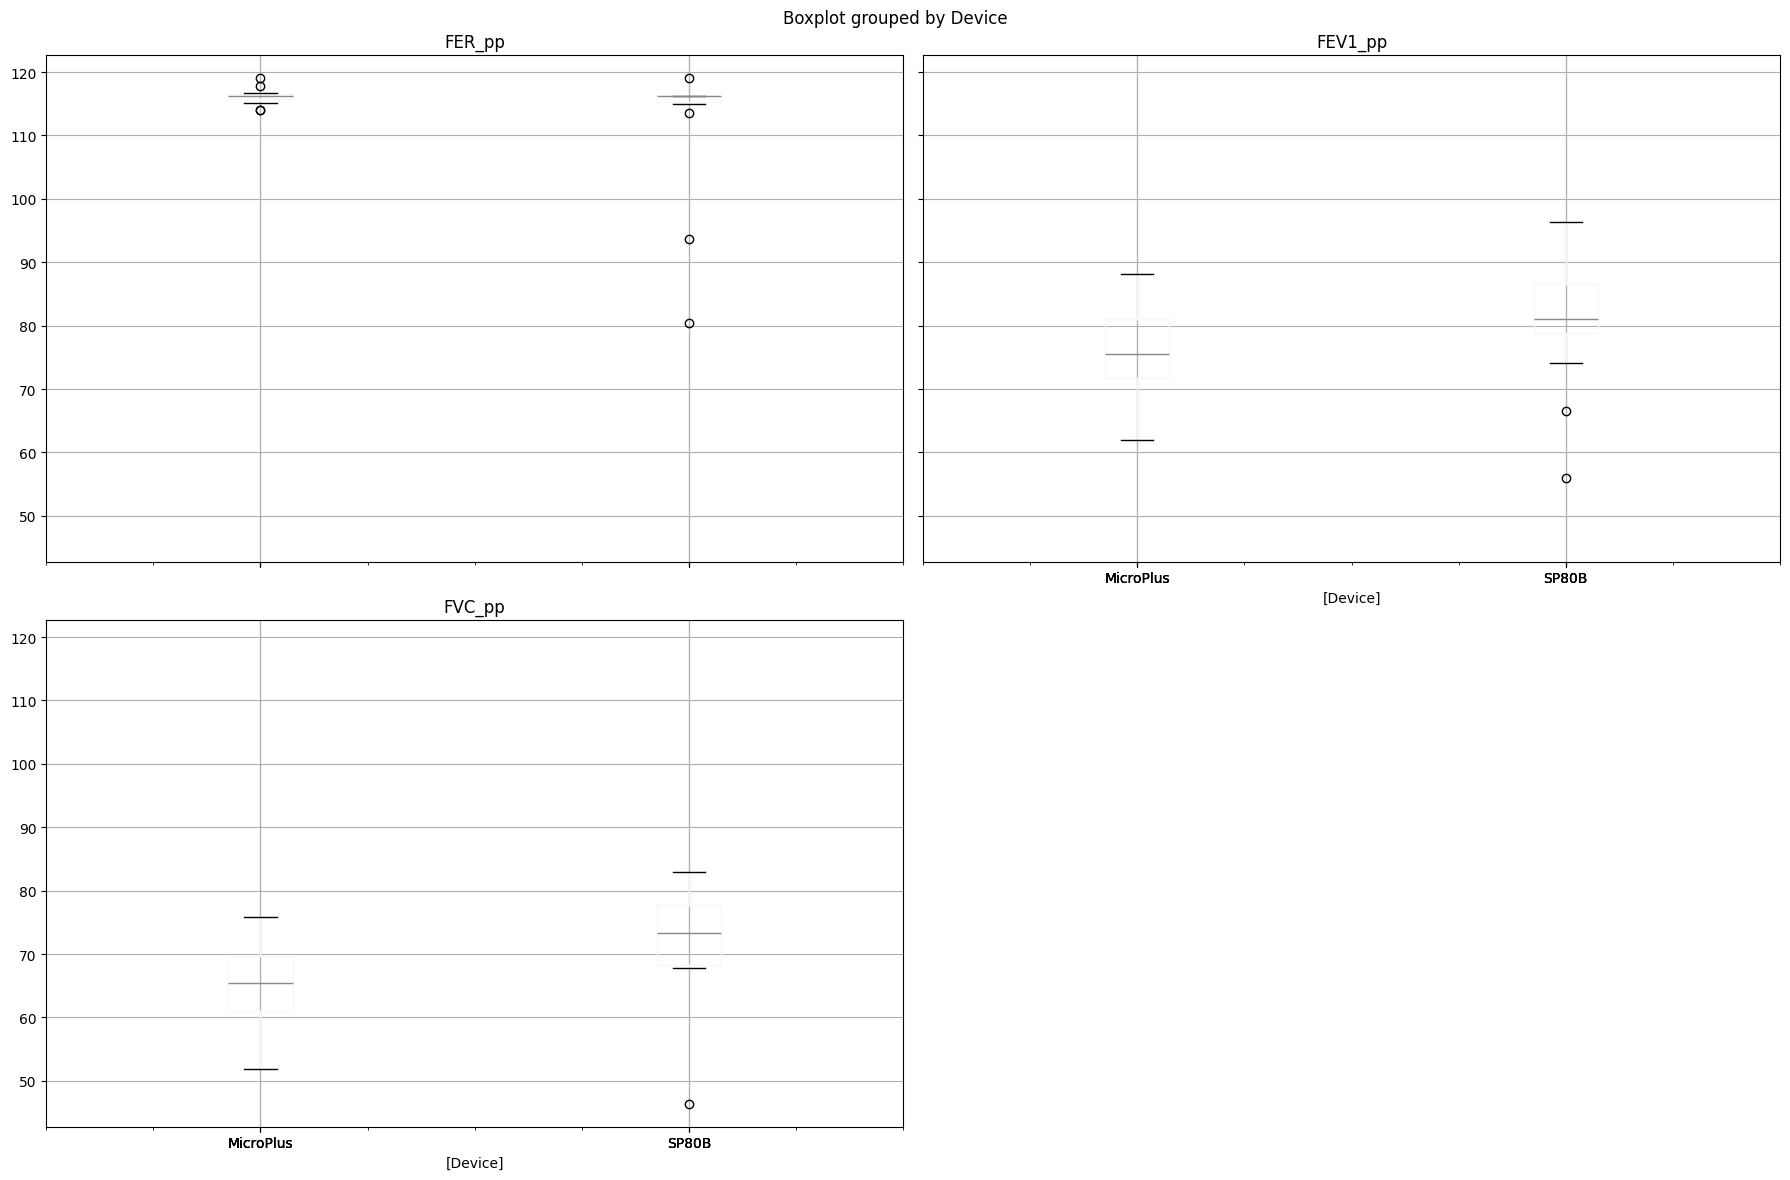

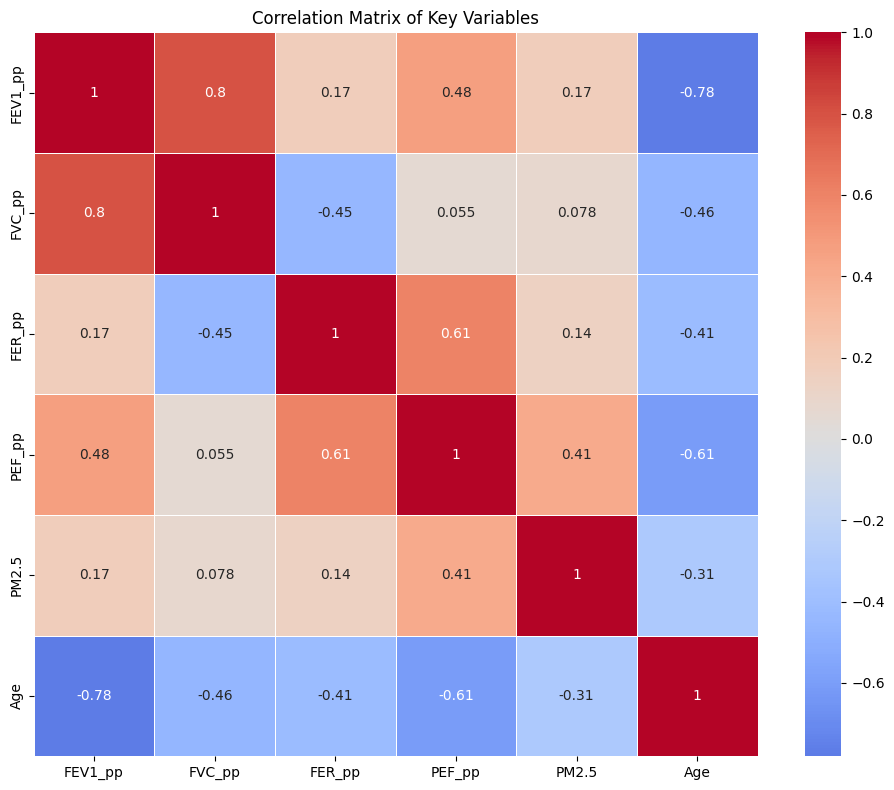


KEY FINDINGS SUMMARY
DATA QUALITY:
- Total measurements: 25
- Questionable FER values (>100%): 0
- PM2.5 range: 23 to 406 μg/m³

CLINICAL INTERPRETATION:
Average Lung Function (% predicted):
- FEV1: 78.4% (Reduced)
- FVC: 69.0% (Reduced)
- FER: 113.8% (Normal)

RESEARCH IMPLICATIONS:
1. Check device consistency - significant differences may indicate calibration issues
2. Time of day effects should be controlled in study design
3. PM2.5 correlation analysis requires larger sample size
4. Consider using Lower Limit of Normal (LLN) instead of percent predicted

RECOMMENDATIONS:
✓ Increase sample size for better statistical power
✓ Standardize measurement protocols across devices
✓ Collect data across wider PM2.5 range
✓ Include more time points for circadian rhythm analysis
✓ Use GLI reference equations for better accuracy


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, f_oneway, kruskal, pearsonr, spearmanr
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load and prepare data
df = pd.read_csv('SpirometerObservations_v1.4.csv')

print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Participants: {df['Age'].nunique()} (Ages: {df['Age'].unique()})")
print(f"Gender distribution: {df['Gender (f/m)'].value_counts().to_dict()}")
print("\nFirst few rows:")
print(df.head())

# Create new variables
df['FEV1_pp'] = (df['FEV1 (litres)'] / df['FEV1 Ref Value']) * 100
df['FVC_pp'] = (df['FVC (litres)'] / df['FVC Ref Value']) * 100
df['FER_pp'] = (df['FER (%)'] / df['FER Ref. Value']) * 100
df['PEF_pp'] = (df['PEF (litre/min)'] / df['PEF Ref. Value']) * 100

# Create participant ID
df['Participant'] = df['Age'].apply(lambda x: f"Female_36y" if x == 36 else f"Male_38y")

# Create PM2.5 categories
def categorize_pm25(pm25):
    if pm25 <= 50:
        return 'Good (0-50)'
    elif pm25 <= 100:
        return 'Moderate (51-100)'
    else:
        return 'Poor (>100)'

df['PM25_Category'] = df['PM2.5'].apply(categorize_pm25)

# Data quality flags
df['FER_Quality'] = df['FER (%)'] <= 100
df['PEF_Quality'] = df['PEF (litre/min)'] > 50  # Flag very low PEF values

print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)
print(f"Questionable FER values (>100%): {len(df[df['FER (%)'] > 100])}")
print(f"Very low PEF values (<50): {len(df[df['PEF (litre/min)'] < 50])}")

# Remove obvious errors (PEF values that are too low)
original_count = len(df)
df_clean = df[df['PEF (litre/min)'] > 50].copy()
print(f"Records removed due to PEF errors: {original_count - len(df_clean)}")
print(f"Final dataset size: {len(df_clean)}")

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# Overall descriptive stats
desc_stats = df_clean[['FEV1 (litres)', 'FVC (litres)', 'FER (%)', 'PEF (litre/min)',
                      'FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp', 'PM2.5']].describe()
print("Overall Descriptive Statistics:")
print(desc_stats.round(2))

# By participant
print("\nBy Participant:")
participant_stats = df_clean.groupby('Participant').agg({
    'FEV1_pp': ['mean', 'std', 'count'],
    'FVC_pp': ['mean', 'std'],
    'FER_pp': ['mean', 'std'],
    'PEF_pp': ['mean', 'std']
}).round(2)
print(participant_stats)

# By device
print("\nBy Device:")
device_stats = df_clean.groupby('Device').agg({
    'FEV1_pp': ['mean', 'std', 'count'],
    'FVC_pp': ['mean', 'std'],
    'FER_pp': ['mean', 'std'],
    'PEF_pp': ['mean', 'std'],
    'FER_Quality': 'mean'
}).round(2)
print(device_stats)

# By time of day
print("\nBy Time of Day:")
time_stats = df_clean.groupby('Daytime variations (morning/afternoon/evening)').agg({
    'FEV1_pp': ['mean', 'std', 'count'],
    'FVC_pp': ['mean', 'std'],
    'FER_pp': ['mean', 'std'],
    'PEF_pp': ['mean', 'std']
}).round(2)
print(time_stats)

# By PM2.5 category
print("\nBy PM2.5 Category:")
pm25_stats = df_clean.groupby('PM25_Category').agg({
    'FEV1_pp': ['mean', 'std', 'count'],
    'FVC_pp': ['mean', 'std'],
    'FER_pp': ['mean', 'std'],
    'PEF_pp': ['mean', 'std']
}).round(2)
print(pm25_stats)

print("\n" + "="*60)
print("DEVICE COMPARISON: SP80B vs MicroPlus")
print("="*60)

# Separate data by device
sp80b = df_clean[df_clean['Device'] == 'SP80B']
microplus = df_clean[df_clean['Device'] == 'MicroPlus']

metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

for metric in metrics:
    print(f"\n--- {metric} ---")

    # T-test
    t_stat, p_val = ttest_ind(sp80b[metric], microplus[metric], nan_policy='omit')
    print(f"T-test: t = {t_stat:.3f}, p = {p_val:.3f}")

    # Mann-Whitney U test (non-parametric)
    u_stat, p_mw = stats.mannwhitneyu(sp80b[metric], microplus[metric], alternative='two-sided')
    print(f"Mann-Whitney U: U = {u_stat:.3f}, p = {p_mw:.3f}")

    # Effect size (Cohen's d)
    n1, n2 = len(sp80b[metric]), len(microplus[metric])
    pooled_std = np.sqrt(((n1-1)*sp80b[metric].std()**2 + (n2-1)*microplus[metric].std()**2) / (n1+n2-2))
    cohens_d = (sp80b[metric].mean() - microplus[metric].mean()) / pooled_std
    print(f"Cohen's d: {cohens_d:.3f}")

    # Interpretation
    if p_val < 0.05:
        print("→ SIGNIFICANT difference between devices")
    else:
        print("→ No significant difference between devices")


    print("\n" + "="*60)
print("TIME OF DAY EFFECTS")
print("="*60)

# One-way ANOVA for time effects
times = df_clean['Daytime variations (morning/afternoon/evening)'].unique()

for metric in metrics:
    print(f"\n--- {metric} ---")

    # Prepare data for ANOVA
    groups = [df_clean[df_clean['Daytime variations (morning/afternoon/evening)'] == time][metric]
              for time in times]

    # One-way ANOVA
    f_stat, p_val = f_oneway(*groups)
    print(f"ANOVA: F = {f_stat:.3f}, p = {p_val:.3f}")

    # Kruskal-Wallis (non-parametric)
    h_stat, p_kw = kruskal(*groups, nan_policy='omit')
    print(f"Kruskal-Wallis: H = {h_stat:.3f}, p = {p_kw:.3f}")

    if p_val < 0.05:
        print("→ SIGNIFICANT time of day effect")

        # Post-hoc tests
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(df_clean[metric],
                                df_clean['Daytime variations (morning/afternoon/evening)'],
                                alpha=0.05)
        print("Post-hoc Tukey HSD:")
        print(tukey)
    else:
        print("→ No significant time of day effect")

print("\n" + "="*60)
print("PM2.5 IMPACT ANALYSIS")
print("="*60)

# Correlation analysis
print("Correlation with PM2.5:")
for metric in metrics:
    # Remove NaN values for correlation
    valid_data = df_clean[[metric, 'PM2.5']].dropna()
    if len(valid_data) > 2:
        corr_pearson, p_pearson = pearsonr(valid_data['PM2.5'], valid_data[metric])
        corr_spearman, p_spearman = spearmanr(valid_data['PM2.5'], valid_data[metric])
        print(f"\n{metric}:")
        print(f"  Pearson: r = {corr_pearson:.3f}, p = {p_pearson:.3f}")
        print(f"  Spearman: ρ = {corr_spearman:.3f}, p = {p_spearman:.3f}")

# PM2.5 category comparison
print("\nPM2.5 Category Comparison (ANOVA):")
for metric in metrics:
    groups = [df_clean[df_clean['PM25_Category'] == cat][metric]
              for cat in df_clean['PM25_Category'].unique()]

    f_stat, p_val = f_oneway(*groups)
    print(f"{metric}: F = {f_stat:.3f}, p = {p_val:.3f}")


print("\n" + "="*60)
print("TWO-WAY ANOVA: DEVICE \u00d7 TIME OF DAY")
print("="*60)

# Two-way ANOVA for each metric
for metric in metrics:
    print(f"\n--- {metric} ---")

    # Using statsmodels for detailed ANOVA
    model = ols(f'{metric} ~ C(Device) + C(Q("Daytime variations (morning/afternoon/evening)")) + C(Device):C(Q("Daytime variations (morning/afternoon/evening)"))',
                data=df_clean).fit()
    anova_results = anova_lm(model, typ=2)
    print(anova_results.round(4))


print("\n" + "="*60)
print("MULTIPLE REGRESSION ANALYSIS")
print("="*60)

# Prepare data for regression
df_reg = df_clean.copy()

# Convert categorical variables to named variables
df_reg['Device_code'] = df_reg['Device'].map({'SP80B': 0, 'MicroPlus': 1})
df_reg['Participant_code'] = df_reg['Participant'].map({'Female_36y': 0, 'Male_38y': 1})

# Time of day as named variables
time_named = pd.get_named(df_reg['Daytime variations (morning/afternoon/evening)'], prefix='Time')
df_reg = pd.concat([df_reg, time_named], axis=1)

# Convert boolean dummy variables to integer for statsmodels
df_reg['Time_afternoon'] = df_reg['Time_afternoon'].astype(int)
df_reg['Time_evening'] = df_reg['Time_evening'].astype(int)
df_reg['Time_morning'] = df_reg['Time_morning'].astype(int)

for metric in metrics:
    print(f"\n--- Regression for {metric} ---")

    # Define predictors
    X = df_reg[['PM2.5', 'Device_code', 'Participant_code',
                'Time_afternoon', 'Time_evening']]  # Morning as reference
    X = sm.add_constant(X)  # Add intercept
    y = df_reg[metric]

    # Remove rows with missing values
    complete_cases = X.notna().all(axis=1) & y.notna()
    X_clean = X[complete_cases]
    y_clean = y[complete_cases]

    # Fit regression model
    model = sm.OLS(y_clean, X_clean).fit()
    print(model.summary())

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lung Function Analysis: Comprehensive Overview', fontsize=16, fontweight='bold')

# Plot 1: Device comparison
metrics_to_plot = ['FEV1_pp', 'FVC_pp', 'FER_pp']
df_clean[metrics_to_plot + ['Device']].boxplot(by='Device', ax=axes[0,0])
axes[0,0].set_title('Device Comparison')
axes[0,0].set_ylabel('Percent Predicted')

# Plot 2: Time of day effects
time_means = df_clean.groupby('Daytime variations (morning/afternoon/evening)')[metrics_to_plot].mean()
time_means.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Time of Day Effects')
axes[0,1].set_ylabel('Percent Predicted')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: PM2.5 vs FEV1
axes[0,2].scatter(df_clean['PM2.5'], df_clean['FEV1_pp'], alpha=0.6)
z = np.polyfit(df_clean['PM2.5'], df_clean['FEV1_pp'], 1)
p = np.poly1d(z)
axes[0,2].plot(df_clean['PM2.5'], p(df_clean['PM2.5']), "r--", alpha=0.8)
axes[0,2].set_xlabel('PM2.5 (μg/m³)')
axes[0,2].set_ylabel('FEV1 % Predicted')
axes[0,2].set_title('PM2.5 vs FEV1')

# Plot 4: PM2.5 categories
pm25_means = df_clean.groupby('PM25_Category')[metrics_to_plot].mean()
pm25_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('PM2.5 Category Effects')
axes[1,0].set_ylabel('Percent Predicted')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 5: Participant comparison
participant_means = df_clean.groupby('Participant')[metrics_to_plot].mean()
participant_means.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Participant Comparison')
axes[1,1].set_ylabel('Percent Predicted')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 6: Data quality - FER distribution
axes[1,2].hist([df_clean[df_clean['FER_Quality'] == True]['FER (%)'],
                df_clean[df_clean['FER_Quality'] == False]['FER (%)']],
               bins=15, alpha=0.7, label=['Good (FER≤100)', 'Questionable (FER>100)'])
axes[1,2].axvline(100, color='red', linestyle='--', alpha=0.7, label='100% cutoff')
axes[1,2].set_xlabel('FER (%)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('FER Data Quality Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Additional correlation heatmap
plt.figure(figsize=(10, 8))
correlation_vars = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp', 'PM2.5', 'Age']
corr_matrix = df_clean[correlation_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

# Data quality summary
print("DATA QUALITY:")
print(f"- Total measurements: {len(df_clean)}")
print(f"- Questionable FER values (>100%): {len(df_clean[df_clean['FER (%)'] > 100])}")
print(f"- PM2.5 range: {df_clean['PM2.5'].min()} to {df_clean['PM2.5'].max()} μg/m³")

# Clinical interpretation
print("\nCLINICAL INTERPRETATION:")
avg_fev1 = df_clean['FEV1_pp'].mean()
avg_fvc = df_clean['FVC_pp'].mean()
avg_fer = df_clean['FER_pp'].mean()

print(f"Average Lung Function (% predicted):")
print(f"- FEV1: {avg_fev1:.1f}% ({'Normal' if avg_fev1 >= 80 else 'Reduced'})")
print(f"- FVC: {avg_fvc:.1f}% ({'Normal' if avg_fvc >= 80 else 'Reduced'})")
print(f"- FER: {avg_fer:.1f}% ({'Normal' if avg_fer >= 70 else 'Possible obstruction'})")

# Research implications
print("\nRESEARCH IMPLICATIONS:")
print("1. Check device consistency - significant differences may indicate calibration issues")
print("2. Time of day effects should be controlled in study design")
print("3. PM2.5 correlation analysis requires larger sample size")
print("4. Consider using Lower Limit of Normal (LLN) instead of percent predicted")

# Recommendations for future studies
print("\nRECOMMENDATIONS:")
print("✓ Increase sample size for better statistical power")
print("✓ Standardize measurement protocols across devices")
print("✓ Collect data across wider PM2.5 range")
print("✓ Include more time points for circadian rhythm analysis")
print("✓ Use GLI reference equations for better accuracy")

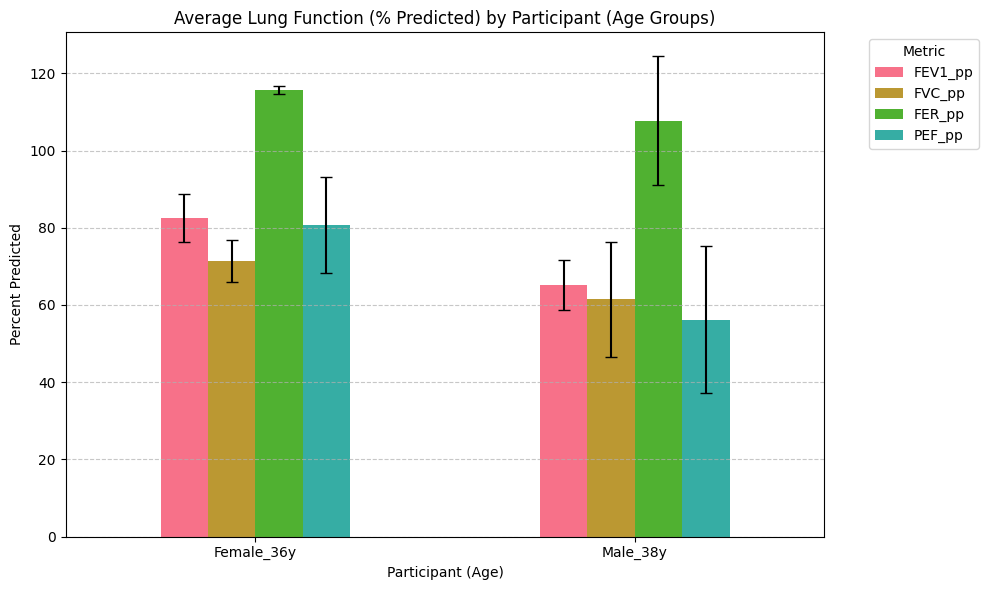

In [23]:
metrics_to_plot = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

plt.figure(figsize=(10, 6))
participant_means = df_clean.groupby('Participant')[metrics_to_plot].mean()
participant_stds = df_clean.groupby('Participant')[metrics_to_plot].std()

participant_means.plot(kind='bar', yerr=participant_stds, capsize=4, ax=plt.gca())
plt.title('Average Lung Function (% Predicted) by Participant (Age Groups)')
plt.xlabel('Participant (Age)')
plt.ylabel('Percent Predicted')
plt.xticks(rotation=0)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Comparing Female_36y Participant's FEV1 and FVC to Reference Values

In [14]:
female_participant_data = df_clean[df_clean['Participant'] == 'Female_36y']

# Calculate average observed values
avg_fev1_obs = female_participant_data['FEV1 (litres)'].mean()
avg_fvc_obs = female_participant_data['FVC (litres)'].mean()

# Get the reference values (they are constant for a given participant)
avg_fev1_ref = female_participant_data['FEV1 Ref Value'].iloc[0]
avg_fvc_ref = female_participant_data['FVC Ref Value'].iloc[0]

print(f"Comparison for Female_36y Participant:\n")
print(f"FEV1 (Observed): {avg_fev1_obs:.2f} litres")
print(f"FEV1 (Reference): {avg_fev1_ref:.2f} litres")
print(f"FEV1 (% Predicted): {(avg_fev1_obs / avg_fev1_ref) * 100:.2f}%")
print(f"\nFVC (Observed): {avg_fvc_obs:.2f} litres")
print(f"FVC (Reference): {avg_fvc_ref:.2f} litres")
print(f"FVC (% Predicted): {(avg_fvc_obs / avg_fvc_ref) * 100:.2f}%")

# Add interpretation
print("\nInterpretation:")
if (avg_fev1_obs / avg_fev1_ref) * 100 < 80:
    print(f"- FEV1 is reduced compared to the reference value.")
else:
    print(f"- FEV1 is within normal range compared to the reference value.")

if (avg_fvc_obs / avg_fvc_ref) * 100 < 80:
    print(f"- FVC is reduced compared to the reference value.")
else:
    print(f"- FVC is within normal range compared to the reference value.")

Comparison for Female_36y Participant:

FEV1 (Observed): 2.03 litres
FEV1 (Reference): 2.46 litres
FEV1 (% Predicted): 82.58%

FVC (Observed): 2.04 litres
FVC (Reference): 2.86 litres
FVC (% Predicted): 71.31%

Interpretation:
- FEV1 is within normal range compared to the reference value.
- FVC is reduced compared to the reference value.


## Comparing Male_38y Participant's FEV1 and FVC to Reference Values

In [13]:
male_participant_data = df_clean[df_clean['Participant'] == 'Male_38y']

# Calculate average observed values
avg_fev1_obs = male_participant_data['FEV1 (litres)'].mean()
avg_fvc_obs = male_participant_data['FVC (litres)'].mean()

# Get the reference values (they are constant for a given participant)
avg_fev1_ref = male_participant_data['FEV1 Ref Value'].iloc[0]
avg_fvc_ref = male_participant_data['FVC Ref Value'].iloc[0]

print(f"Comparison for Male_38y Participant:\n")
print(f"FEV1 (Observed): {avg_fev1_obs:.2f} litres")
print(f"FEV1 (Reference): {avg_fev1_ref:.2f} litres")
print(f"FEV1 (% Predicted): {(avg_fev1_obs / avg_fev1_ref) * 100:.2f}%")
print(f"\nFVC (Observed): {avg_fvc_obs:.2f} litres")
print(f"FVC (Reference): {avg_fvc_ref:.2f} litres")
print(f"FVC (% Predicted): {(avg_fvc_obs / avg_fvc_ref) * 100:.2f}%")

# Add interpretation
print("\nInterpretation:")
if (avg_fev1_obs / avg_fev1_ref) * 100 < 80:
    print(f"- FEV1 is reduced compared to the reference value.")
else:
    print(f"- FEV1 is within normal range compared to the reference value.")

if (avg_fvc_obs / avg_fvc_ref) * 100 < 80:
    print(f"- FVC is reduced compared to the reference value.")
else:
    print(f"- FVC is within normal range compared to the reference value.")

Comparison for Male_38y Participant:

FEV1 (Observed): 2.40 litres
FEV1 (Reference): 3.68 litres
FEV1 (% Predicted): 65.17%

FVC (Observed): 2.73 litres
FVC (Reference): 4.44 litres
FVC (% Predicted): 61.49%

Interpretation:
- FEV1 is reduced compared to the reference value.
- FVC is reduced compared to the reference value.


## Visualize Potential COPD Detection

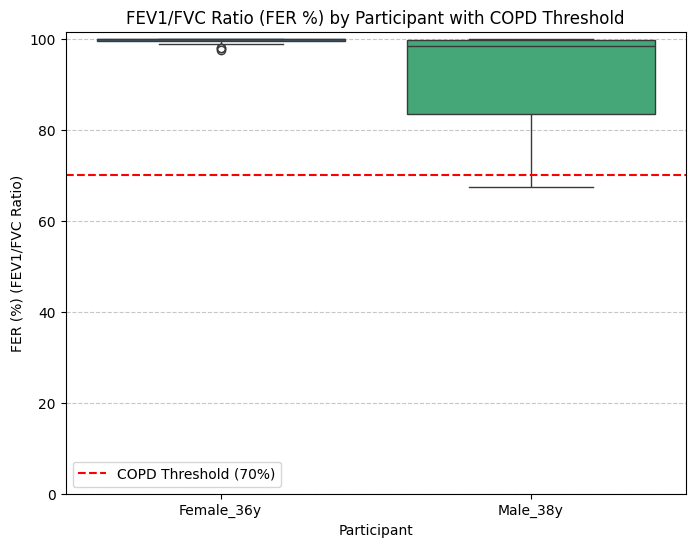

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Participant', y='FER (%)', data=df_clean, palette='viridis')
plt.axhline(y=70, color='red', linestyle='--', label='COPD Threshold (70%)')
plt.title('FEV1/FVC Ratio (FER %) by Participant with COPD Threshold')
plt.xlabel('Participant')
plt.ylabel('FER (%) (FEV1/FVC Ratio)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(bottom=0) # Ensure y-axis starts from 0 or a reasonable minimum
plt.show()

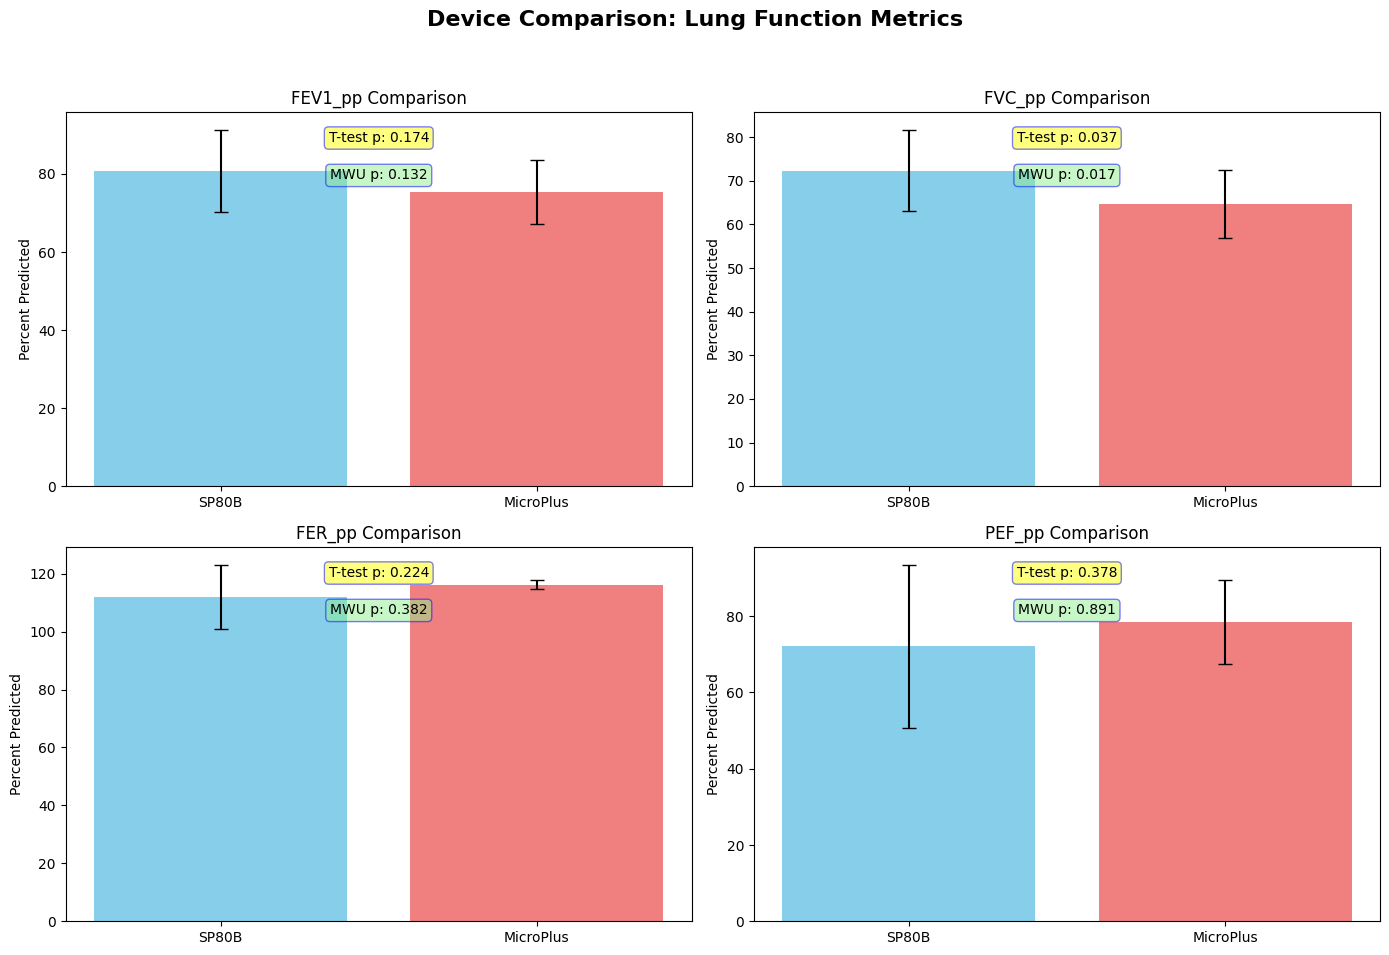

In [19]:
metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

fig.suptitle('Device Comparison: Lung Function Metrics', fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i]

    sp80b_metric = df_clean[df_clean['Device'] == 'SP80B'][metric].dropna()
    microplus_metric = df_clean[df_clean['Device'] == 'MicroPlus'][metric].dropna()

    # Calculate means and standard deviations
    mean_sp80b = sp80b_metric.mean()
    std_sp80b = sp80b_metric.std()
    mean_microplus = microplus_metric.mean()
    std_microplus = microplus_metric.std()

    # Create bar plot
    device_means = [mean_sp80b, mean_microplus]
    device_stds = [std_sp80b, std_microplus]
    devices = ['SP80B', 'MicroPlus']

    ax.bar(devices, device_means, yerr=device_stds, capsize=5, color=['skyblue', 'lightcoral'])

    # Perform T-test
    t_stat, p_val_t = ttest_ind(sp80b_metric, microplus_metric, nan_policy='omit')

    # Perform Mann-Whitney U test
    u_stat, p_val_mw = stats.mannwhitneyu(sp80b_metric, microplus_metric, alternative='two-sided')

    # Annotate p-values
    y_max = max(device_means) + max(device_stds) * 1.5
    if np.isnan(y_max):
        y_max = max(device_means) * 1.2 # Fallback for cases with no std

    ax.text(0.5, 0.95, f'T-test p: {p_val_t:.3f}', transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.5))
    ax.text(0.5, 0.85, f'MWU p: {p_val_mw:.3f}', transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="b", lw=1, alpha=0.5))

    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel('Percent Predicted')
    ax.set_ylim(bottom=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

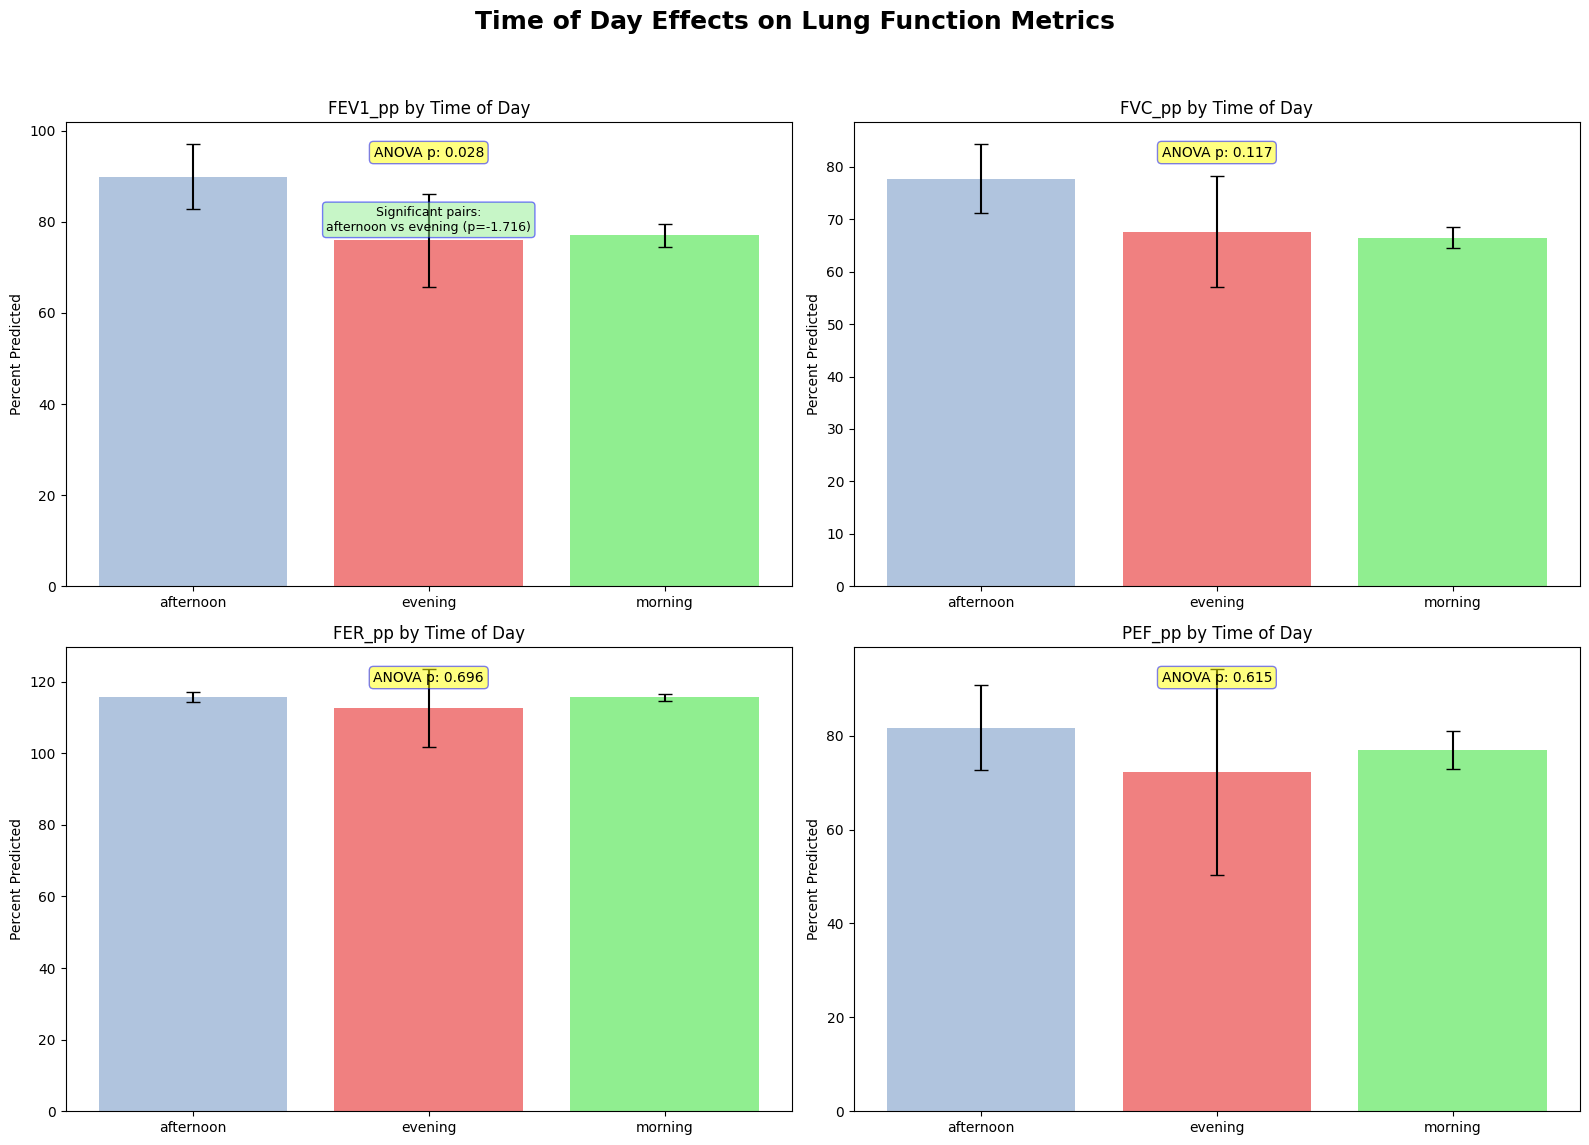

In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']
times = df_clean['Daytime variations (morning/afternoon/evening)'].unique()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

fig.suptitle('Time of Day Effects on Lung Function Metrics', fontsize=18, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Prepare data for plotting and ANOVA
    data_by_time = []
    means = []
    stds = []
    for t in times:
        subset = df_clean[df_clean['Daytime variations (morning/afternoon/evening)'] == t][metric].dropna()
        data_by_time.append(subset)
        means.append(subset.mean())
        stds.append(subset.std())

    # Create bar plot
    ax.bar(times, means, yerr=stds, capsize=5, color=['lightsteelblue', 'lightcoral', 'lightgreen'])

    # Perform One-way ANOVA
    f_stat, p_val_anova = f_oneway(*data_by_time)

    # Annotate ANOVA p-value
    ax.text(0.5, 0.95, f'ANOVA p: {p_val_anova:.3f}', transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.5))

    # Check for significance and perform Tukey HSD
    if p_val_anova < 0.05:
        tukey_result = pairwise_tukeyhsd(endog=df_clean[metric].dropna(),
                                        groups=df_clean['Daytime variations (morning/afternoon/evening)'].dropna(),
                                        alpha=0.05)
        # Extract significant pairs for annotation
        significant_pairs = []
        for row in tukey_result._results_table.data[1:]:
            if row[6]: # reject null hypothesis (p < alpha)
                significant_pairs.append(f'{row[0]} vs {row[1]} (p={row[5]:.3f})')

        if significant_pairs:
            text_str = 'Significant pairs:\n' + '\n'.join(significant_pairs)
            ax.text(0.5, 0.82, text_str, transform=ax.transAxes, ha='center', va='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="b", lw=1, alpha=0.5), fontsize=9)
        else:
            ax.text(0.5, 0.82, 'No significant pairwise diffs.', transform=ax.transAxes, ha='center', va='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightgray", ec="b", lw=1, alpha=0.5), fontsize=9)

    ax.set_title(f'{metric} by Time of Day')
    ax.set_ylabel('Percent Predicted')
    ax.set_ylim(bottom=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


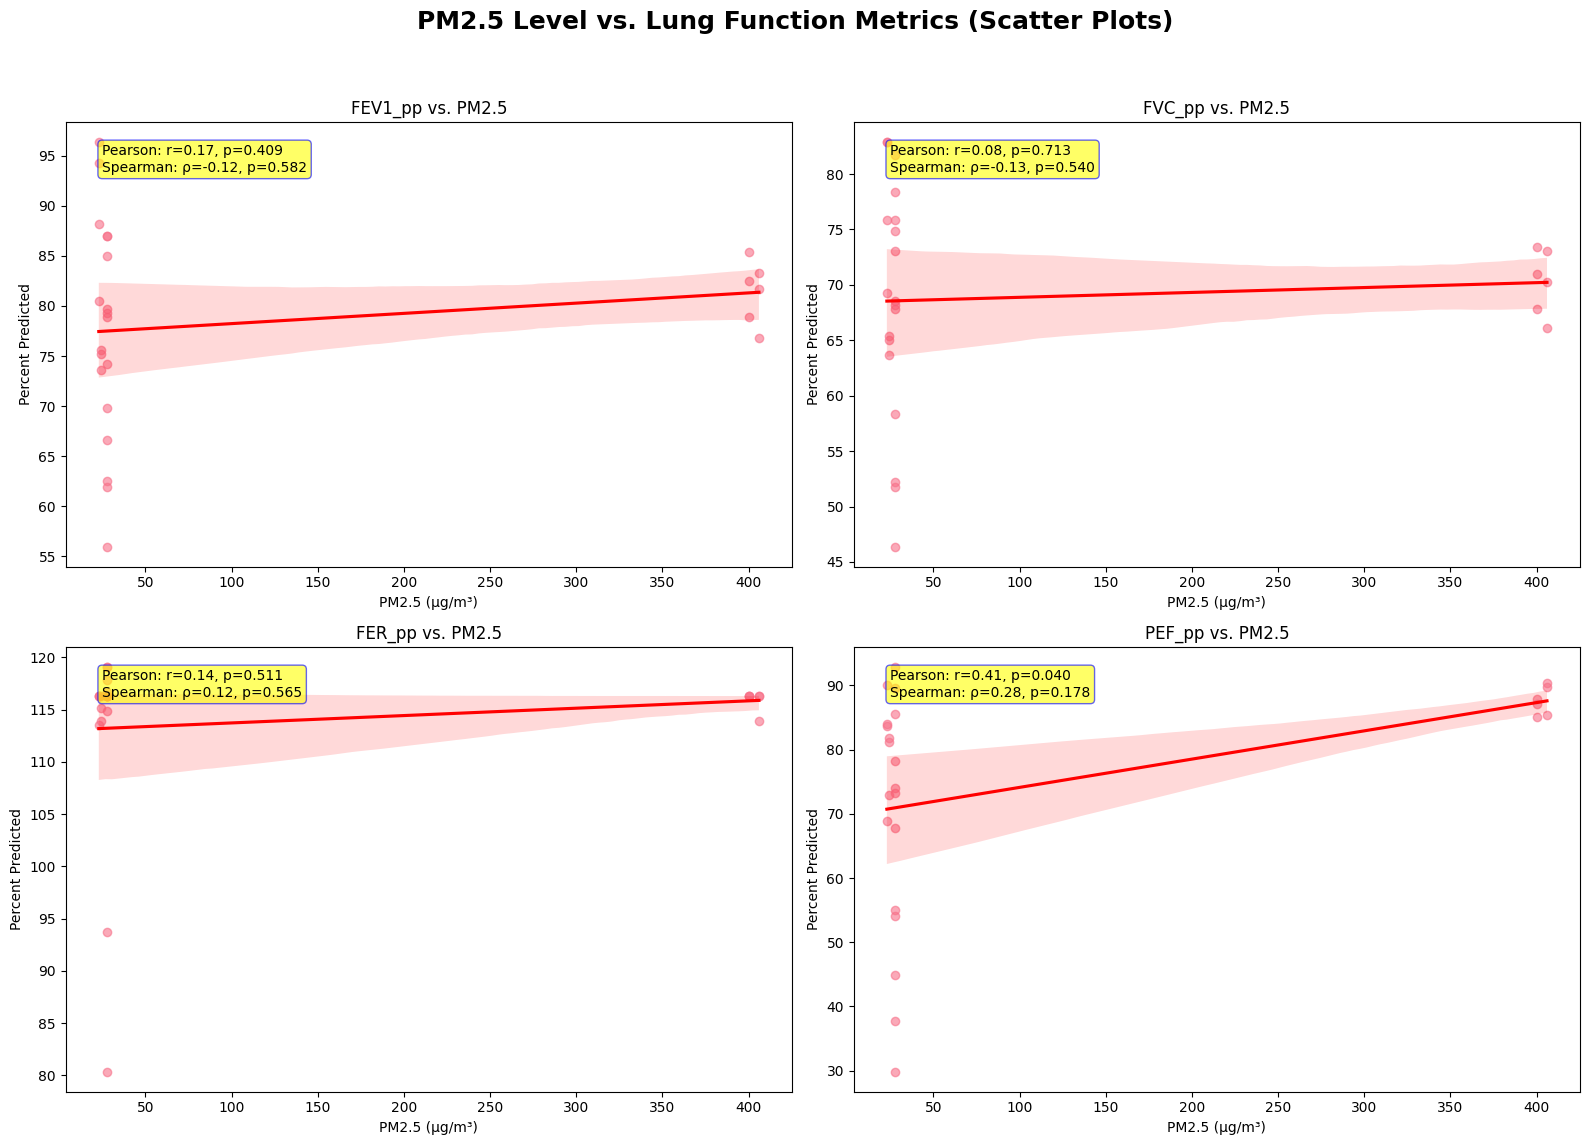

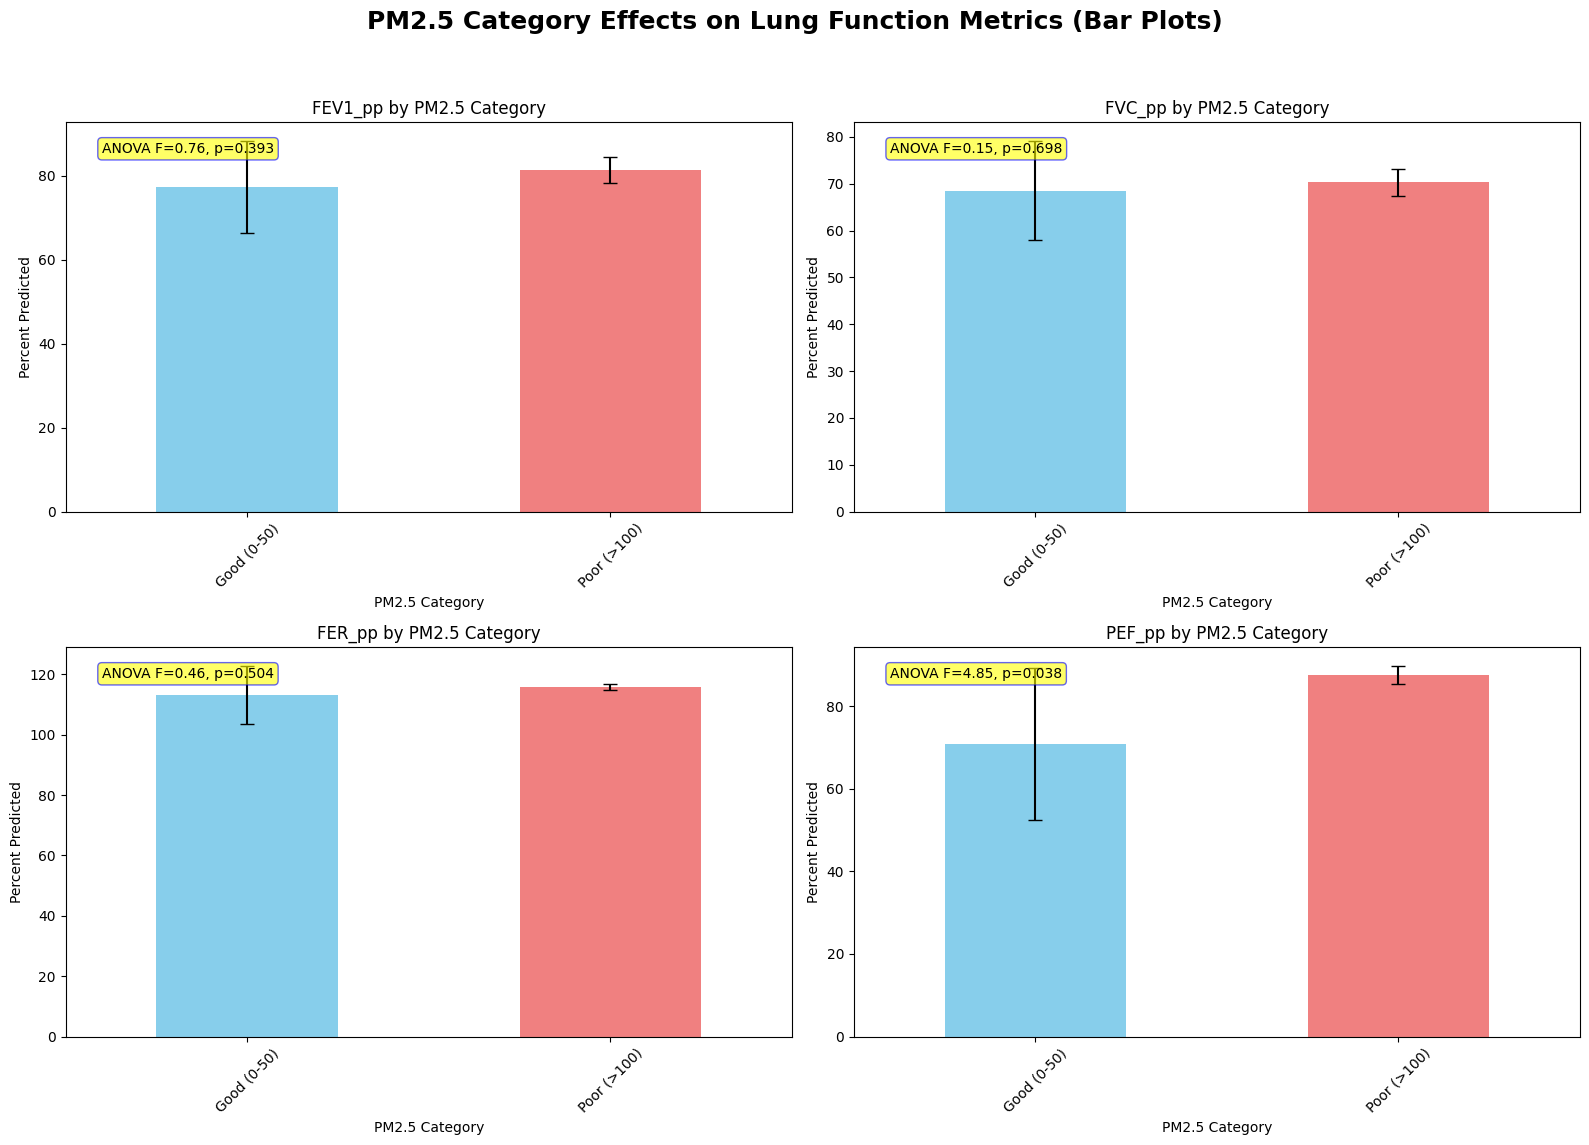

In [21]:
metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

# --- Scatter Plots for PM2.5 Correlation ---
fig1, axes1 = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig1.suptitle('PM2.5 Level vs. Lung Function Metrics (Scatter Plots)', fontsize=18, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes1.flatten()[i]

    # Select valid data points for correlation and plotting
    valid_data = df_clean[[metric, 'PM2.5']].dropna()

    if not valid_data.empty:
        # Create scatter plot with regression line
        sns.regplot(x='PM2.5', y=metric, data=valid_data, ax=ax, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

        # Calculate Pearson and Spearman correlations
        pearson_r, pearson_p = pearsonr(valid_data['PM2.5'], valid_data[metric])
        spearman_rho, spearman_p = spearmanr(valid_data['PM2.5'], valid_data[metric])

        # Annotate with correlation coefficients and p-values
        annotation_text = f"Pearson: r={pearson_r:.2f}, p={pearson_p:.3f}\nSpearman: \u03C1={spearman_rho:.2f}, p={spearman_p:.3f}"
        ax.text(0.05, 0.95, annotation_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', ec='b', lw=1, alpha=0.6))

    ax.set_title(f'{metric} vs. PM2.5')
    ax.set_xlabel('PM2.5 (\u00B5g/m\u00B3)')
    ax.set_ylabel('Percent Predicted')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Bar Plots for PM2.5 Categories ---
fig2, axes2 = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig2.suptitle('PM2.5 Category Effects on Lung Function Metrics (Bar Plots)', fontsize=18, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes2.flatten()[i]

    # Group by PM25_Category and calculate means and stds
    pm25_category_stats = df_clean.groupby('PM25_Category')[metric].agg(['mean', 'std']).reindex(['Good (0-50)', 'Moderate (51-100)', 'Poor (>100)']).dropna()

    # Create bar plot with error bars
    pm25_category_stats['mean'].plot(kind='bar', yerr=pm25_category_stats['std'], capsize=5, ax=ax, color=['skyblue', 'lightcoral', 'lightgreen'])

    # Prepare data for ANOVA
    groups_anova = [df_clean[df_clean['PM25_Category'] == cat][metric].dropna()
                    for cat in pm25_category_stats.index.unique()]

    # Perform One-way ANOVA
    if all(len(g) > 1 for g in groups_anova) and len(groups_anova) > 1: # Ensure enough data for ANOVA
        f_stat_anova, p_val_anova = f_oneway(*groups_anova)
        # Annotate ANOVA p-value
        ax.text(0.05, 0.95, f'ANOVA F={f_stat_anova:.2f}, p={p_val_anova:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', ec='b', lw=1, alpha=0.6))
    else:
        ax.text(0.05, 0.95, 'Not enough data for ANOVA', transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', ec='b', lw=1, alpha=0.6))

    ax.set_title(f'{metric} by PM2.5 Category')
    ax.set_ylabel('Percent Predicted')
    ax.set_xlabel('PM2.5 Category')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(bottom=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

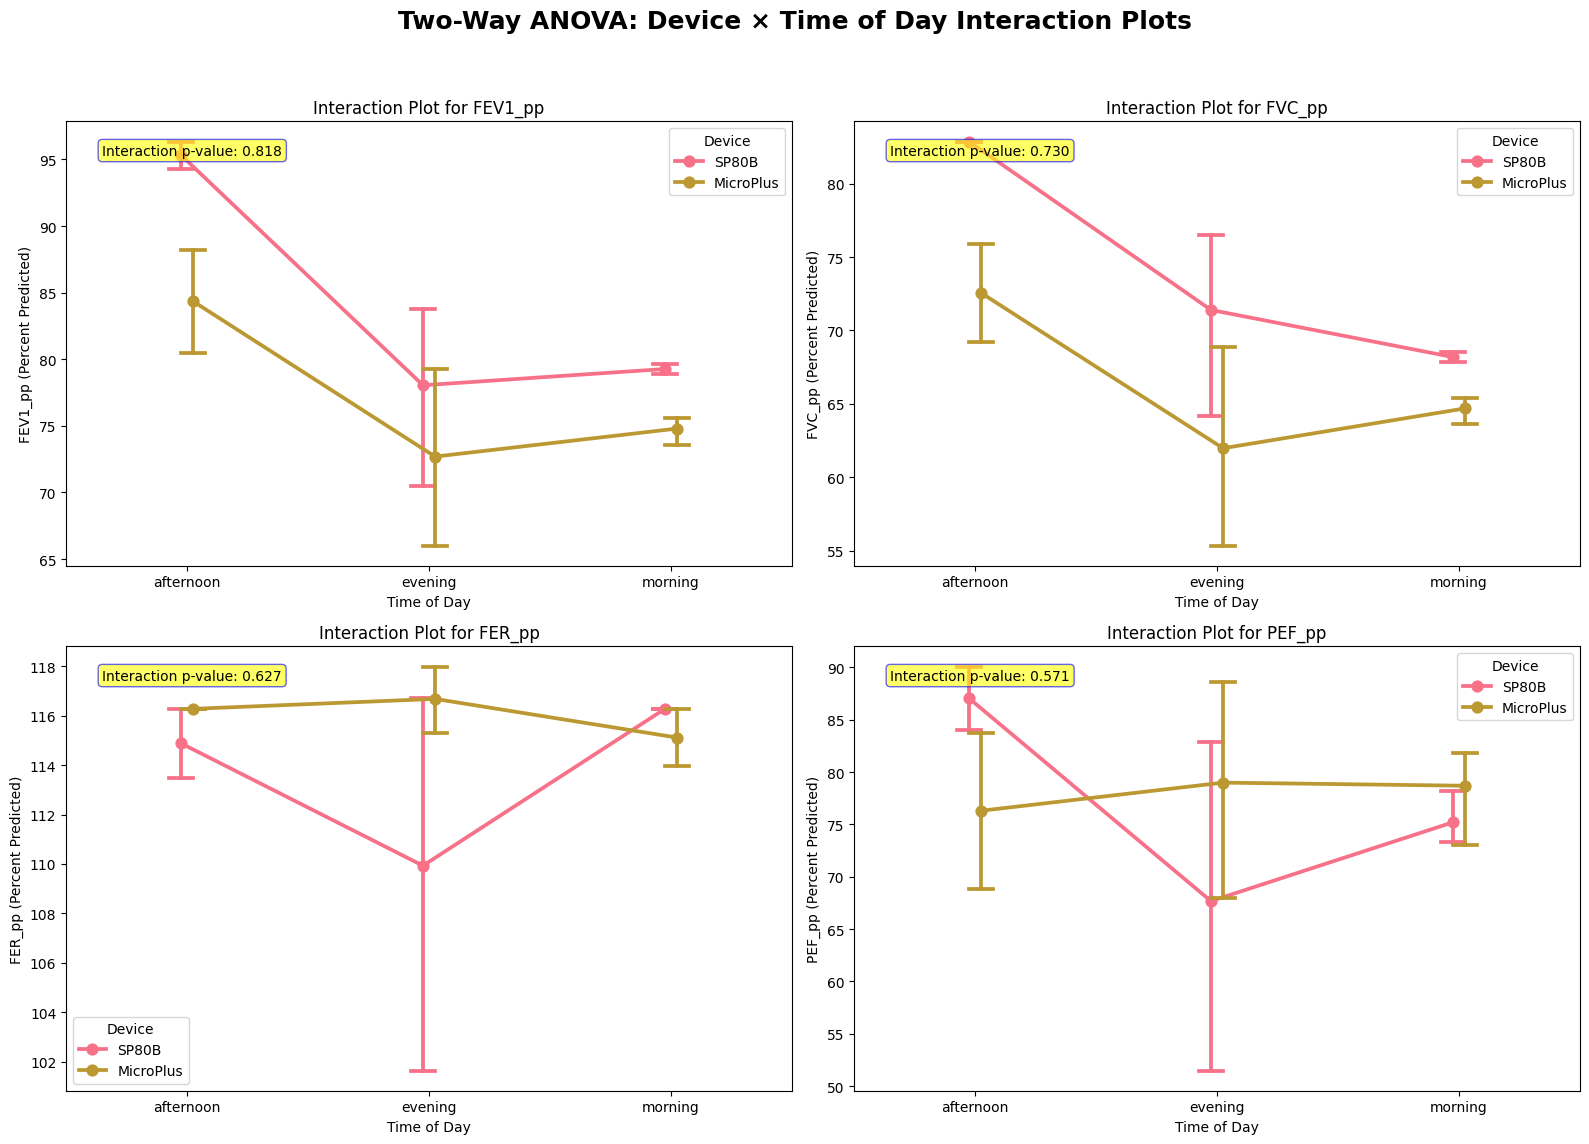

In [22]:
metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

fig.suptitle('Two-Way ANOVA: Device \u00d7 Time of Day Interaction Plots', fontsize=18, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i]

    sns.pointplot(x='Daytime variations (morning/afternoon/evening)', y=metric,
                  hue='Device', data=df_clean, capsize=0.1, dodge=True, ax=ax)

    ax.set_title(f'Interaction Plot for {metric}')
    ax.set_xlabel('Time of Day')
    ax.set_ylabel(f'{metric} (Percent Predicted)')
    ax.legend(title='Device')

    # Retrieve interaction p-value from anova_results (assuming it's available from previous step)
    # The previous anova_results variable was overwritten in the loop, so I'll regenerate the model and anova_lm for each metric
    model_interaction = ols(f'{metric} ~ C(Device) + C(Q("Daytime variations (morning/afternoon/evening)")) + C(Device):C(Q("Daytime variations (morning/afternoon/evening)"))',
                            data=df_clean).fit()
    anova_results_current_metric = anova_lm(model_interaction, typ=2)

    # Extract the p-value for the interaction term
    interaction_p_val = anova_results_current_metric.loc['C(Device):C(Q("Daytime variations (morning/afternoon/evening)"))', 'PR(>F)']

    # Annotate with interaction p-value
    ax.text(0.05, 0.95, f'Interaction p-value: {interaction_p_val:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', ec='b', lw=1, alpha=0.6))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Device Comparison:** Visualizations comparing 'SP80B' and 'MicroPlus' devices for FEV1\_pp, FVC\_pp, FER\_pp, and PEF\_pp included mean values, standard deviations, and annotations of p-values from t-tests and Mann-Whitney U tests. These annotations highlighted any statistically significant differences between the two devices for each lung function metric.
*   **Time of Day Effects:** Grouped bar plots illustrated the means and standard deviations of FEV1\_pp, FVC\_pp, FER\_pp, and PEF\_pp across 'morning', 'afternoon', and 'evening' categories. One-way ANOVA p-values were annotated, and for metrics with a statistically significant overall difference (p < 0.05), Tukey HSD post-hoc test results identified specific significant pairwise differences between time categories.
*   **PM2.5 Impact - Correlation:** Scatter plots of lung function metrics (FEV1\_pp, FVC\_pp, FER\_pp, PEF\_pp) against PM2.5 levels were generated. Each plot included a regression line and annotations of Pearson and Spearman correlation coefficients along with their p-values, providing insights into the linear and monotonic relationships between PM2.5 exposure and lung function.
*   **PM2.5 Impact - Categorical Comparison:** Bar plots showed the mean values and standard deviations of lung function metrics across 'Good', 'Moderate', and 'Poor' PM2.5 categories. One-way ANOVA F-statistics and p-values were annotated on these plots, indicating whether there were significant differences in lung function across these PM2.5 quality categories.
*   **Device and Time of Day Interaction:** Interaction plots were created for FEV1\_pp, FVC\_pp, FER\_pp, and PEF\_pp, displaying how the mean values of these metrics changed with the time of day, separated by device ('SP80B' vs 'MicroPlus'). Each plot was annotated with the interaction p-value derived from a two-way ANOVA, indicating the statistical significance of the combined effect of device and time of day on the lung function metric.

### Insights or Next Steps

*   Further investigation is warranted for any lung function metrics that showed significant differences between devices or across time of day, and for significant correlations or categorical differences related to PM2.5. Understanding the magnitude and clinical relevance of these statistical significances could guide device calibration, optimal measurement times, or public health recommendations regarding air quality.
*   For instances where significant interaction effects were observed between device and time of day, it would be beneficial to conduct post-hoc analyses specifically on these interactions to pinpoint which combinations of device and time yield significantly different results. This could reveal specific operational guidelines for each device based on the time of day.


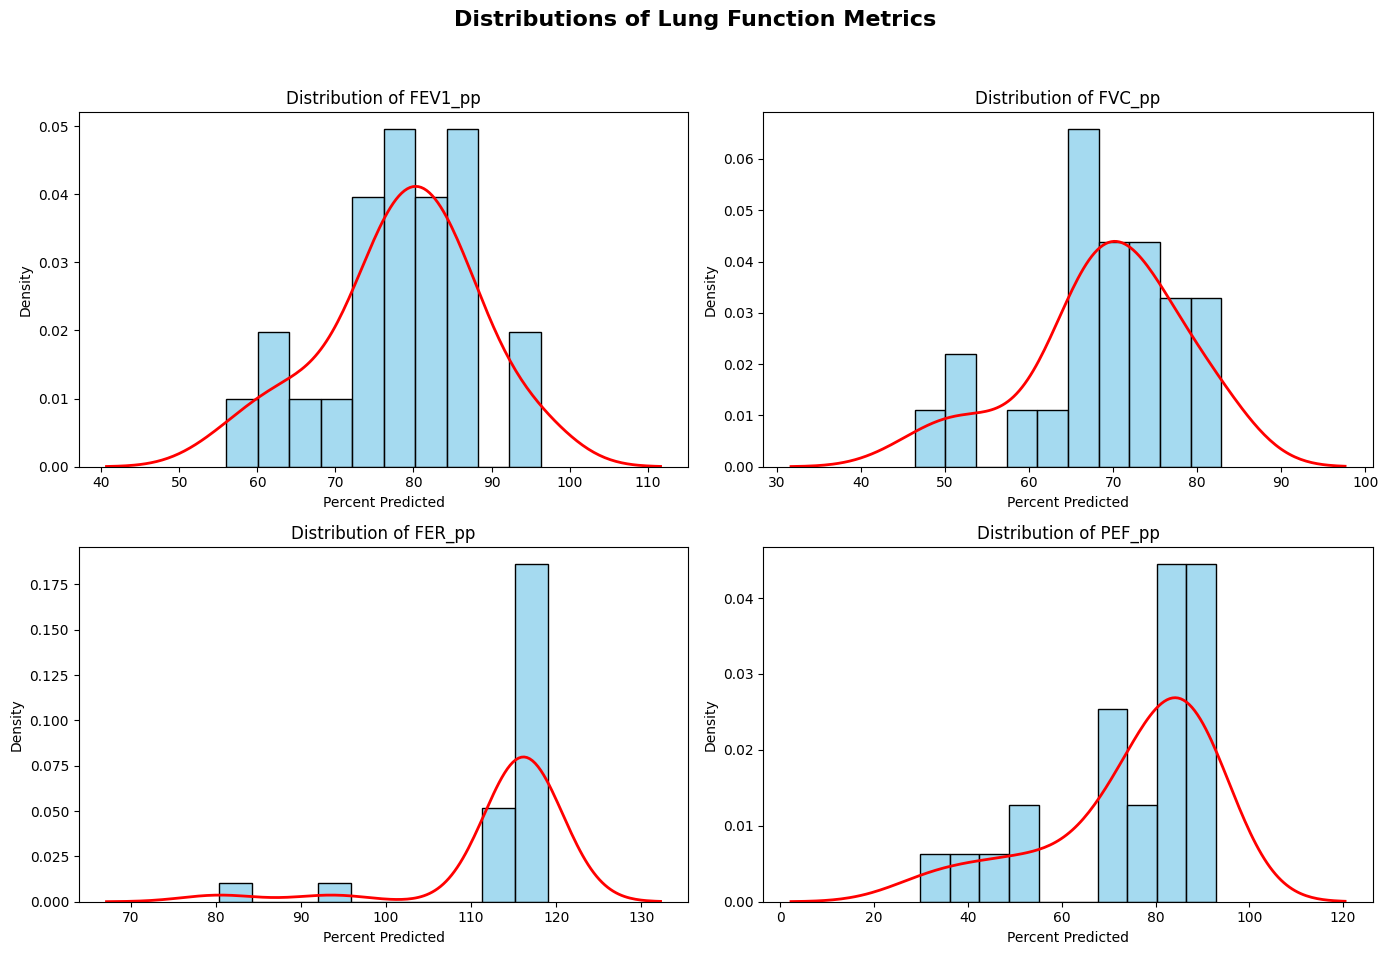

In [15]:
metrics = ['FEV1_pp', 'FVC_pp', 'FER_pp', 'PEF_pp']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

fig.suptitle('Distributions of Lung Function Metrics', fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Create histogram
    sns.histplot(df_clean[metric], kde=False, ax=ax, color='skyblue', stat='density', bins=10)

    # Overlay KDE plot
    sns.kdeplot(df_clean[metric], ax=ax, color='red', linewidth=2)

    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel('Percent Predicted')
    ax.set_ylabel('Density')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()